In [1]:
import bw2data, bw2io
#from premise import *
#import bw_timex
from bw_timex import TimexLCA
from bw_temporalis import TemporalDistribution, easy_timedelta_distribution
import numpy as np
from datetime import datetime

In [2]:
# activate the bw project
bw2data.projects.set_current("ei311")
for db in bw2data.databases:
    print(db, len(bw2data.Database(db)))

ecoinvent-3.11-biosphere 9795
ecoinvent-3.11-cutoff 25412
ei_cutoff_3.11_remind_SSP2-NDC_2030 2025-11-21 37360
ei_cutoff_3.11_remind_SSP2-NDC_2040 2025-11-21 37361
ei_cutoff_3.11_remind_SSP2-NDC_2050 2025-11-21 37361
ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22 41755
ei_cutoff_3.11_image_SSP5-H_2040 2025-11-22 41759
ei_cutoff_3.11_image_SSP5-H_2050 2025-11-22 41762
ei_cutoff_3.11_image_SSP1-VLLO_2050 2025-11-22 41789
ei_cutoff_3.11_image_SSP2-M_2030 2025-11-22 41754
ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22 41789
ei_cutoff_3.11_image_SSP2-M_2040 2025-11-22 41759
ei_cutoff_3.11_image_SSP2-M_2050 2025-11-22 41762
ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24 41774
elec_foreground 1


## step1: prepare dynamic LCI 

In [24]:
image_ssp1_db_2030 = bw2data.Database("ei_cutoff_3.11_image_SSP1-VLLO_2030 2025-11-24")
image_ssp1_db_2040 = bw2data.Database("ei_cutoff_3.11_image_SSP1-VLLO_2040 2025-11-22")
image_ssp5_db_2030 = bw2data.Database("ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22")
image_ssp5_db_2040 = bw2data.Database("ei_cutoff_3.11_image_SSP5-H_2040 2025-11-22")

In [11]:
if "elec_foreground" in bw2data.databases:
    del bw2data.databases["elec_foreground"]  
foreground = bw2data.Database("elec_foreground")
foreground.register()

### create new foreground DB
#### need foreground helper:: 
- depending on which location, e.g., CAN, or any other location provided by the premise background database, we'll create a final elec_highvol_loc_1kwh, as the new foreground activity to be assigned with dynamic inventory 

####  need background SSP/year mapping helper:: 
- e.g., if we're studying 2030 elec grid for image_ssp1, then using the image_ssp1_db_2030 background database to search for bw2_act: "market group for electricity, high voltage", also location == user-input location e.g., "CAN"

In [10]:
elec_ssp1_2040_production = image_ssp5_db_2040.get(name="market group for electricity, high voltage", location="CAN")
print(elec_ssp1_2040_production)

'market group for electricity, high voltage' (kilowatt hour, CAN, None)


In [12]:
elec_highvol_CAN_1kwh = foreground.new_node("elec_highvol_CAN_1kwh", 
                                            name="electricity mix, high voltage, Canada", 
                                            location = "CAN", unit="kWh")

elec_highvol_CAN_1kwh['reference product'] = "one kWh electricity mix, high voltage"
elec_highvol_CAN_1kwh.new_edge(input=elec_highvol_CAN_1kwh, amount=1, type="production").save()

### because temporal_distribution MUST be attached to the exchange, not the activity in bw_temporalis ###
input_elec_to_highvol_CAN_1kwh = elec_highvol_CAN_1kwh.new_edge(
    input=elec_ssp1_2040_production,
    amount=1,
    type="technosphere",
)

elec_highvol_CAN_1kwh.save()

In [13]:
len(elec_highvol_CAN_1kwh.technosphere())

0

In [14]:
elec_highvol_CAN_1kwh.as_dict()

{'database': 'elec_foreground',
 'code': 'elec_highvol_CAN_1kwh',
 'location': 'CAN',
 'name': 'electricity mix, high voltage, Canada',
 'unit': 'kWh',
 'reference product': 'one kWh electricity mix, high voltage'}

In [15]:
input_elec_to_highvol_CAN_1kwh

Exchange: 1 kilowatt hour 'market group for electricity, high voltage' (kilowatt hour, CAN, None) to 'electricity mix, high voltage, Canada' (kWh, CAN, None)>

<Axes: xlabel='Time (Years)', ylabel='Amount'>

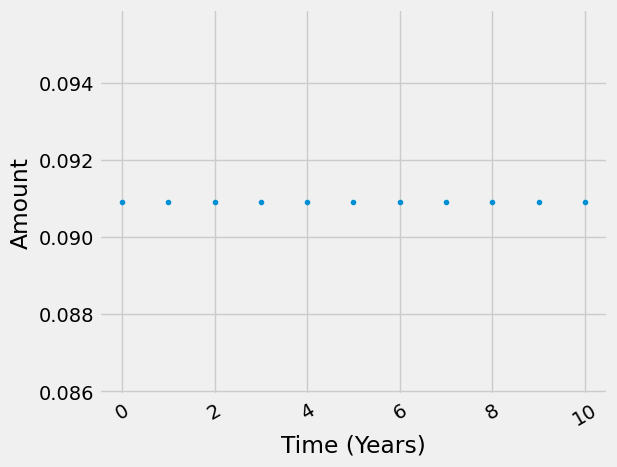

In [16]:
elec_MY = 10

td_elec = easy_timedelta_distribution(
    start=0,
    end=elec_MY,
    resolution="Y",
    steps=(elec_MY + 1),
    kind="uniform",  
)
td_elec.graph(resolution="Y") 
# if `M` month resolution, so later tlca.build_timeline(temporal_grouping="month") 

In [17]:
input_elec_to_highvol_CAN_1kwh["temporal_distribution"] = td_elec
input_elec_to_highvol_CAN_1kwh.save()

## map to background premise

#### mapping foreground -> background datetime helper:: 
- it's important to choose the right background database and datetime for the dynamic foreground:
- e.g., if we're studying 2040&ssp1 electricity, like above elec_ssp1_2040_production = image_ssp1_db_2040.get, then the database_dates ={} below use the same SSP/year e.g.,  image_ssp1_db_2040.name: datetime.strptime("2040", "%Y"),

    
    database_dates = {
        #image_ssp1_db_2030.name: datetime.strptime("2030", "%Y"),
        image_ssp1_db_2040.name: datetime.strptime("2040", "%Y"),
        #image_ssp1_db_2050.name: datetime.strptime("2050", "%Y"),
        "elec_foreground": "dynamic", # flag databases that should be temporally distributed with "dynamic"
    }

In [25]:
database_dates = {
    image_ssp5_db_2030.name: datetime.strptime("2030", "%Y"),
    image_ssp5_db_2040.name: datetime.strptime("2040", "%Y"),
    #image_ssp1_db_2050.name: datetime.strptime("2050", "%Y"),
    "elec_foreground": "dynamic", # flag databases that should be temporally distributed with "dynamic"
}

database_dates

{'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22': datetime.datetime(2030, 1, 1, 0, 0),
 'ei_cutoff_3.11_image_SSP5-H_2040 2025-11-22': datetime.datetime(2040, 1, 1, 0, 0),
 'elec_foreground': 'dynamic'}

### ready to instanciate tlca
#### method need to MATCH the SSP/YEAR chosen

In [26]:
method =  ('Climate Change prospective GWP100',
  'SSP585',
  'MY2040',
  'pGWP100 with with dp-AGWPCO2')
#('ecoinvent-3.11', 'IPCC 2021 (incl. biogenic CO2)', 'climate change: total (incl. biogenic CO2, incl. SLCFs)', 'global warming potential (GWP100)')  
#('ecoinvent-3.11', 'CML v4.8 2016', 'climate change', 'global warming potential (GWP100)') 

In [27]:
tlca = TimexLCA({elec_highvol_CAN_1kwh: 1}, method, database_dates)

2025-11-27 08:45:42.711 | INFO     | bw_timex.timex_lca:__init__:114 - Initializing TimexLCA object...
2025-11-27 08:45:42.713 | INFO     | bw_timex.timex_lca:__init__:136 - Collecting node infos...


In [28]:
# build a timeline of the exchanges: if `M` for td, then month here 
tlca.build_timeline(temporal_grouping="year")

2025-11-27 08:46:17.559 | INFO     | bw_timex.timex_lca:build_timeline:216 - No edge filter function provided. Skipping all edges in background databases.
2025-11-27 08:46:29.670 | INFO     | bw_timex.timex_lca:build_timeline:232 - Calculating base LCA...
2025-11-27 08:46:34.576 | INFO     | bw_timex.timex_lca:build_timeline:242 - Creating activity time mapping...
2025-11-27 08:46:35.093 | INFO     | bw_timex.timeline_builder:__init__:99 - Traversing supply chain graph...


Starting graph traversal


2025-11-27 08:46:35.466 | INFO     | bw_timex.timeline_builder:build_timeline:142 - Building timeline...
2025-11-27 08:46:35.534 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-11-27 08:46:35.535 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2026-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-11-27 08:46:35.536 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2027-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2025-11-27 08:46:35.537 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:522 - Reference date 2028-01-01 00:00:00 is lower than all prov

Calculation count: 1


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2026-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22'...
1,2026-01-01,"electricity mix, high voltage, Canada",2026-01-01,-1,1.0,None
2,2027-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22'...
3,2028-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22'...
4,2029-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22'...
5,2030-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22'...
6,2031-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22'...
7,2032-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22'...
8,2033-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22'...
9,2034-01-01,"market group for electricity, high voltage",2026-01-01,"electricity mix, high voltage, Canada",0.090909,{'ei_cutoff_3.11_image_SSP5-H_2030 2025-11-22'...


In [29]:
# calculate the time-explicit LCI, with TimexLCA.lci()
tlca.lci()

2025-11-27 08:46:40.372 | INFO     | bw_timex.timex_lca:lci:360 - Expanding matrices...
2025-11-27 08:46:40.395 | INFO     | bw_timex.timex_lca:lci:379 - Calculating dynamic inventory...


In [30]:
tlca.dynamic_inventory # the new dynamic_inventory that was now created,
# instead of one row for each emission in the biosphere database we now get one row for each emission at each point in time.

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 30577 stored elements and shape (36102, 83527)>

In [31]:
tlca.dynamic_inventory.shape
# w/h three background DB datatime, it becomes (36102, 125365) 

(36102, 83527)

In [32]:
#the dynamic inventory is calculated as a sparse matrix, more human-friendly version as a pandas:
tlca.dynamic_inventory_df.head()

,date,amount,flow,activity
2205,2026-01-01,7.660082,250401799139369058,251340274252521474
607,2026-01-01,5.746698,250401797902049299,251340274252521474
277,2026-01-01,1.430146,250401797688139822,251340274252521474
270,2026-01-01,0.408197,250401797688139804,251340274252521474
1337,2026-01-01,0.407896,250401798346645610,251340274252521474


####  foreground + one background snapshot 

In [33]:
tlca.base_score # this is BW2 static score  foreground + one background snapshot

0.0939048035183141

#### relinking foreground -> time-specific background DBs; score differs ONLY IF multiple BGD-DB selected

In [34]:
### dynamic lci with the static GWP , if only one BGDB selected, almost same score as static LCIA
tlca.static_lcia()
tlca.static_score   #kg CO2-eq
#tlca.static_score  # 0.07955713173198123 if three 2030/2040/2050 BGDG chosen 

0.12740789419722814

In [35]:
#tlca.dynamic_lcia(metric="radiative_forcing", fixed_time_horizon=True)
tlca.dynamic_lcia(metric="GWP", fixed_time_horizon=False, time_horizon = 100)
tlca.dynamic_score

2025-11-27 08:47:09.078 | INFO     | dynamic_characterization.dynamic_characterization:characterize:82 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


0.1513581147761085

## step2:: some plot / analysis on dyn-LCI/LCIA 

### plot dynamic inventory per emission flow

In [23]:
mybio = bw2data.Database('ecoinvent-3.11-biosphere')

In [ ]:
#"Carbon dioxide, in air", with a CF of -1 :: 250401797923020800 
#"Carbon dioxide, non-fossil, resource correction" ::  250401799114203150

In [24]:
#tlca.plot_dynamic_inventory(bio_flows = [250401798745104436]) #ch4-non fossil
#tlca.plot_dynamic_inventory(bio_flows = [250401797683945508]) #ch4-fossil 
#tlca.plot_dynamic_inventory(bio_flows = [250401798669606930]) #co2 

In [25]:
from bw2data import get_activity
print(get_activity(250401798669606930))

'Carbon dioxide, fossil' (kilogram, None, ('air',))


In [26]:
df = tlca.dynamic_inventory_df
df_co2_air = df[df['flow'] == 250401798669606930]   #co2 
df_co2_air

,date,amount,flow,activity
1723,2026-01-01,0.000428,250401798669606930,251340274252521474
4500,2027-01-01,0.000428,250401798669606930,251340274252521476
7277,2028-01-01,0.000428,250401798669606930,251340274252521477
10054,2029-01-01,0.000428,250401798669606930,251340274252521478
12831,2030-01-01,0.000428,250401798669606930,251340274252521479
15614,2031-01-01,0.000239,250401798669606930,251340274252521480
18398,2032-01-01,0.000049,250401798669606930,251340274252521481
21182,2033-01-01,-0.000140,250401798669606930,251340274252521482
23966,2034-01-01,-0.000330,250401798669606930,251340274252521483
26750,2035-01-01,-0.000519,250401798669606930,251340274252521484


###  why  fixed_time_horizon=False: 

- Fixed time horizon means that the time horizon for all emissions (no matter when they occur) starts counting at the time of the functional unit, resulting in shorter time horizons for emissions occuring later. This approach has been proposed by Levasseur et al. 2010 to harmonize the time frame chosen for the analysis and the time period covered by the LCA results. If the time horizon is not fixed (this is what conventional impact assessment factors assume), it starts counting from the timing of the emission.

In [27]:
#tlca.dynamic_lcia(metric="radiative_forcing", fixed_time_horizon=True)
#tlca.dynamic_lcia(metric="GWP", fixed_time_horizon=False, time_horizon = 100)
#tlca.dynamic_score

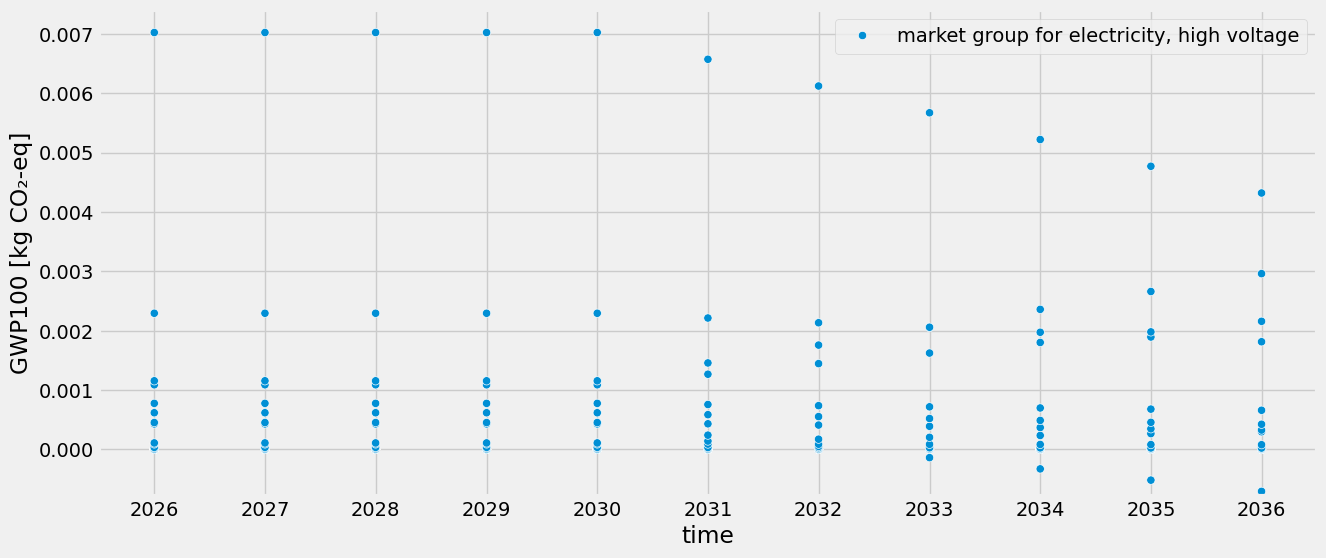

In [28]:
#tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True)
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=False)
#tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True, cumsum=True)

### waterfall to compare GWP100, pGWP100, dpGWP 

In [34]:
s_lci_plcia_scores, d_lci_plcia_scores = {}, {}
''' s_lci_slcia_scores, d_lci_slcia_scores  = {}, {}  ''' 
for exc in elec_highvol_CAN_1kwh.technosphere():    
    #tlca.base_lca.lcia(demand={exc.input.id: exc.amount})
    s_lci_plcia_scores[exc.input["name"]] = tlca.base_score 
    d_lci_plcia_scores[exc.input["name"]] = tlca.static_score 

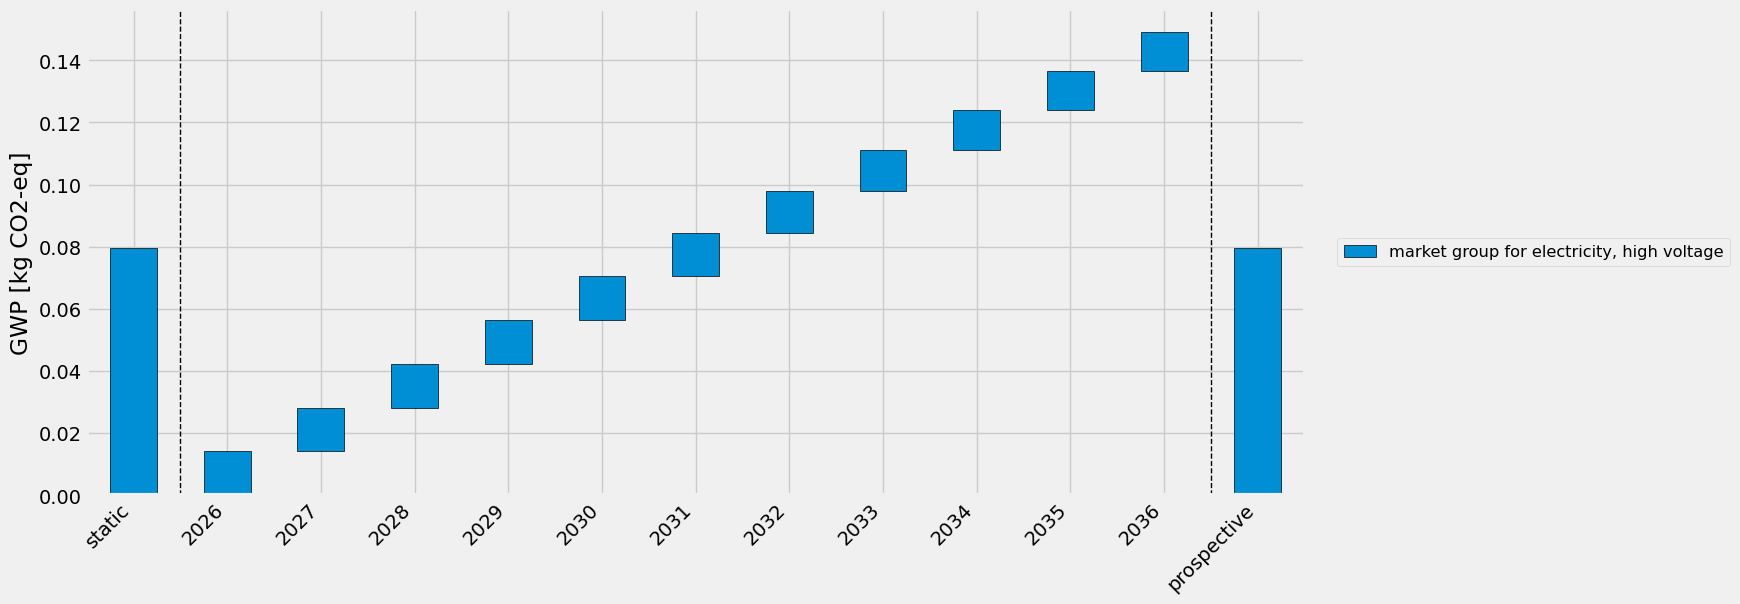

In [35]:
from bw_timex.utils import plot_characterized_inventory_as_waterfall

# only one process
#order_stacked_activities = (    [  elec_highvol_CAN_1kwh["name"] ])

plot_characterized_inventory_as_waterfall(
    tlca,
    static_scores=d_lci_plcia_scores,
    prospective_scores=d_lci_plcia_scores, # caz we use pGWP100 here, the static_score is actuall p_score
    #order_stacked_activities=order_stacked_activities,
)

## negative CO2 (in air) (resource correction) not included in timex_dynCF

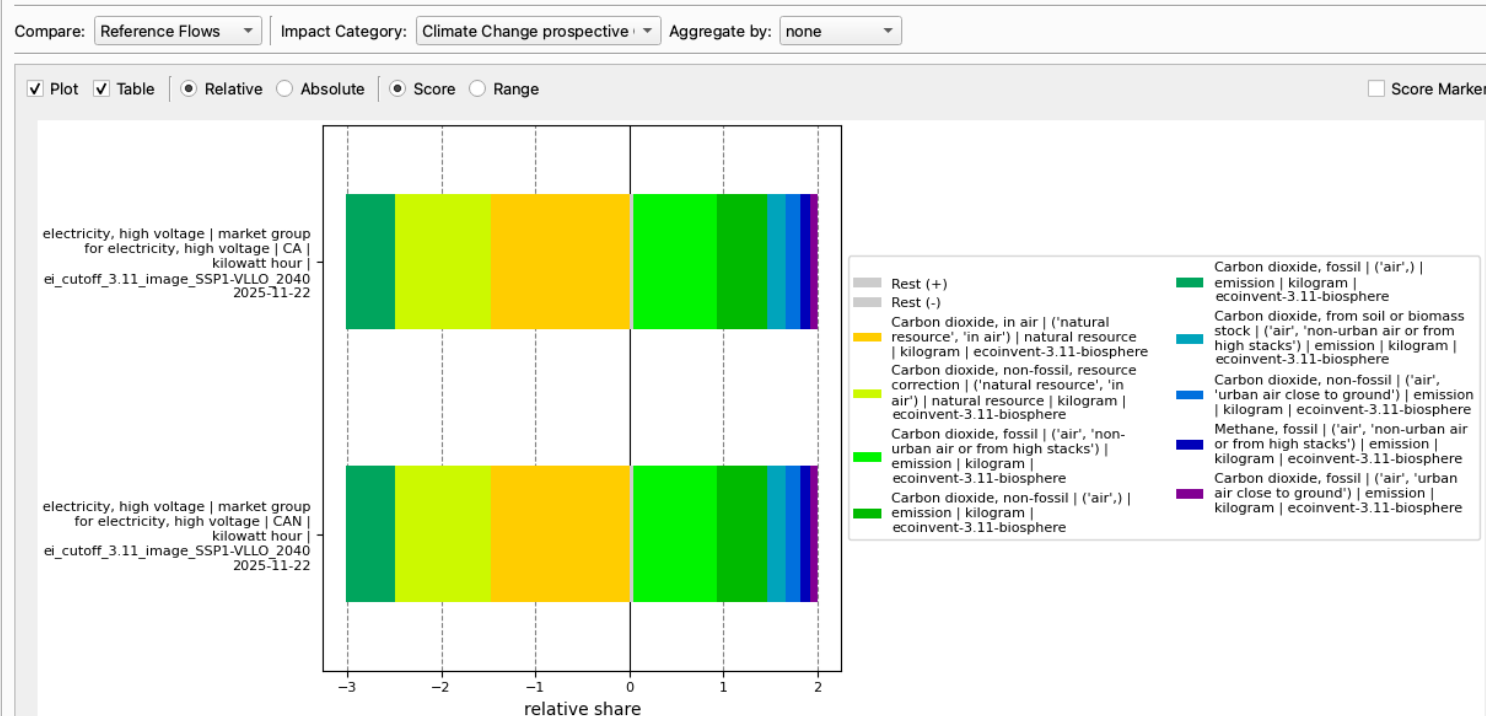

In [36]:
dyn = tlca.characterized_inventory   # after dynamic_lcia
print(dyn.groupby("flow")["amount"].sum().sort_values(ascending=True).head(20))
dyn.head()

flow
250401798443114499   -2.353478e-08
250401797755248709   -1.520849e-08
250401798669606942    7.125244e-16
250401798778658821    2.257397e-15
250401797805580382    1.202907e-14
250401798346645528    2.581188e-14
250401798594109483    1.917231e-13
250401799110008842    3.252716e-13
250401798594109452    5.478835e-13
250401798166290508    9.352182e-13
250401798644441126    5.165164e-12
250401799428775954    6.042085e-12
250401797755248645    9.480546e-12
250401797709111341    4.152221e-11
250401798103375931    4.240620e-11
250401799470718979    5.343610e-11
250401798229205114    7.749556e-11
250401799307141151    1.426791e-10
250401798250176534    1.673712e-10
250401797851717633    5.436434e-10
Name: amount, dtype: float64


,date,amount,flow,activity
0,2026-01-01,-2.106417e-09,250401798443114499,251340274252521474
1,2026-01-01,-1.038446e-09,250401797755248709,251340274252521474
2,2026-01-01,6.314509e-17,250401798669606942,251340274252521474
3,2026-01-01,1.882165e-16,250401798778658821,251340274252521474
4,2026-01-01,1.250078e-15,250401797805580382,251340274252521474


In [37]:
from bw2data import get_activity
print(get_activity(250401797755248709))
print(get_activity(250401798443114499))

'Carbon dioxide, to soil or biomass stock' (kilogram, None, ('soil', 'agricultural'))
'Carbon dioxide, to soil or biomass stock' (kilogram, None, ('soil',))


### these two negative CO2 flows are in the dynLCI, but not dynCF 

In [37]:
dyn = tlca.characterized_inventory 
keys_to_check = {250401797923020800, 250401799114203150}
present_keys = keys_to_check.intersection(dyn['flow'].unique())
if present_keys:
    print("Found key(s):", present_keys)
else:
    print("No keys found")

Found key(s): {250401797923020800, 250401799114203150}


In [61]:
get_activity(250401797923020800)
get_activity(250401799114203150)

'Carbon dioxide, non-fossil, resource correction' (kilogram, None, ('natural resource', 'in air'))

In [39]:
filtered_dyn_negCO2 = dyn[dyn["flow"].isin(keys_to_check)]
filtered_dyn_negCO2

,date,amount,flow,activity
56,2026-01-01,0.000564,250401797923020800,251340274252521474
57,2026-01-01,0.000619,250401799114203150,251340274252521474
118,2027-01-01,0.000564,250401797923020800,251340274252521476
119,2027-01-01,0.000619,250401799114203150,251340274252521476
180,2028-01-01,0.000564,250401797923020800,251340274252521477
181,2028-01-01,0.000619,250401799114203150,251340274252521477
242,2029-01-01,0.000564,250401797923020800,251340274252521478
243,2029-01-01,0.000619,250401799114203150,251340274252521478
304,2030-01-01,0.000564,250401797923020800,251340274252521479
305,2030-01-01,0.000619,250401799114203150,251340274252521479


## step3:: filter out GHG flows, for the new dpGWP LCIA 

In [40]:
mybio = bw2data.Database('ecoinvent-3.11-biosphere')

In [40]:
dyn

,date,amount,flow,activity
0,2026-01-01,-2.106417e-09,250401798443114499,251340274252521474
1,2026-01-01,-1.038446e-09,250401797755248709,251340274252521474
2,2026-01-01,6.314509e-17,250401798669606942,251340274252521474
3,2026-01-01,1.882165e-16,250401798778658821,251340274252521474
4,2026-01-01,1.250078e-15,250401797805580382,251340274252521474
...,...,...,...,...
677,2036-01-01,4.129287e-04,250401798669606930,251340274252521485
678,2036-01-01,6.911955e-04,250401799110008870,251340274252521485
679,2036-01-01,6.981598e-04,250401799630102567,251340274252521485
680,2036-01-01,7.287858e-04,250401799567187993,251340274252521485


In [41]:
uniqff = np.unique(dyn['flow'])
len(uniqff)

62

In [43]:
from bw2data import get_activity
for ff in uniqff: 
    print(get_activity(ff))

'Dinitrogen monoxide' (kilogram, None, ('air', 'non-urban air or from high stacks'))
'Propane' (kilogram, None, ('air', 'non-urban air or from high stacks'))
'Methane, fossil' (kilogram, None, ('air',))
'Propane' (kilogram, None, ('air',))
'Chloroform' (kilogram, None, ('air', 'non-urban air or from high stacks'))
'Butane' (kilogram, None, ('air', 'urban air close to ground'))
'Carbon dioxide, to soil or biomass stock' (kilogram, None, ('soil', 'agricultural'))
'Carbon dioxide, fossil' (kilogram, None, ('air', 'lower stratosphere + upper troposphere'))
'Methane, from soil or biomass stock' (kilogram, None, ('air', 'non-urban air or from high stacks'))
'Butane' (kilogram, None, ('air', 'low population density, long-term'))
'Dinitrogen monoxide' (kilogram, None, ('air', 'low population density, long-term'))
'Ethane' (kilogram, None, ('air',))
'Carbon monoxide, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))
'Carbon dioxide, fossil' (kilogram, None, ('air', 'non-urb

In [44]:
#### for dpIRF we only have three major GHG: 
threeghg = []
for ff in uniqff: 
    if 'Carbon dioxide' in get_activity(ff)['name'] or 'Methane' in  get_activity(ff)['name'] or 'Dinitrogen monoxide' in get_activity(ff)['name']:  
        print(ff, get_activity(ff))
        threeghg.append(ff)
    else:
        pass

250401797516173346 'Dinitrogen monoxide' (kilogram, None, ('air', 'non-urban air or from high stacks'))
250401797683945508 'Methane, fossil' (kilogram, None, ('air',))
250401797755248709 'Carbon dioxide, to soil or biomass stock' (kilogram, None, ('soil', 'agricultural'))
250401797780414511 'Carbon dioxide, fossil' (kilogram, None, ('air', 'lower stratosphere + upper troposphere'))
250401797805580308 'Methane, from soil or biomass stock' (kilogram, None, ('air', 'non-urban air or from high stacks'))
250401797826551837 'Dinitrogen monoxide' (kilogram, None, ('air', 'low population density, long-term'))
250401797876883529 'Carbon dioxide, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))
250401797923020800 'Carbon dioxide, in air' (kilogram, None, ('natural resource', 'in air'))
250401798040461343 'Carbon dioxide, non-fossil' (kilogram, None, ('air', 'urban air close to ground'))
250401798229205044 'Carbon dioxide, from soil or biomass stock' (kilogram, None, ('air',

In [45]:
len(threeghg)

25

In [46]:
majorghg_df = dyn[dyn['flow'].isin(threeghg)].copy() 
majorghg_df

,date,amount,flow,activity
0,2026-01-01,-2.106417e-09,250401798443114499,251340274252521474
1,2026-01-01,-1.038446e-09,250401797755248709,251340274252521474
23,2026-01-01,2.786048e-10,250401798954819704,251340274252521474
27,2026-01-01,2.388418e-09,250401797780414511,251340274252521474
30,2026-01-01,3.131325e-09,250401797805580308,251340274252521474
...,...,...,...,...
677,2036-01-01,4.129287e-04,250401798669606930,251340274252521485
678,2036-01-01,6.911955e-04,250401799110008870,251340274252521485
679,2036-01-01,6.981598e-04,250401799630102567,251340274252521485
680,2036-01-01,7.287858e-04,250401799567187993,251340274252521485


##### after extract the three major GHG flows like this table, then I'll apply my own dynamic IRF (on a timeframe year0-100) for all these flows: e.g., 
impact_2027
= emissions_2027 * IRF(0)
+ emissions_2026 * IRF(1)
+ emissions_2025 * IRF(2)
+ ...
+ 
up till impact_year(2036+100)

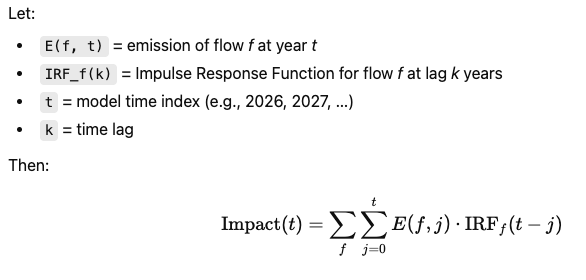

In [47]:
### preserve the flow ID in excel 
majorghg_df["flow"] = majorghg_df["flow"].astype(str)
majorghg_df.to_excel("elec_ssp585-2040.xlsx", index=False) 

In [48]:
majorghg_df

,date,amount,flow,activity
0,2026-01-01,-2.106417e-09,250401798443114499,251340274252521474
1,2026-01-01,-1.038446e-09,250401797755248709,251340274252521474
23,2026-01-01,2.786048e-10,250401798954819704,251340274252521474
27,2026-01-01,2.388418e-09,250401797780414511,251340274252521474
30,2026-01-01,3.131325e-09,250401797805580308,251340274252521474
...,...,...,...,...
677,2036-01-01,4.129287e-04,250401798669606930,251340274252521485
678,2036-01-01,6.911955e-04,250401799110008870,251340274252521485
679,2036-01-01,6.981598e-04,250401799630102567,251340274252521485
680,2036-01-01,7.287858e-04,250401799567187993,251340274252521485


In [68]:
get_activity(250401797683945508)

'Methane, fossil' (kilogram, None, ('air',))

In [58]:
majorghg_df['year'] = majorghg_df['date'].dt.year

pivot = majorghg_df.pivot_table(
    index='year',
    columns='flow',
    values='amount',
    aggfunc='sum'
).fillna(0)
pivot

flow,250401797516173346,250401797683945508,250401797755248709,250401797780414511,250401797805580308,250401797826551837,250401797876883529,250401797923020800,250401798040461343,250401798229205044,...,250401798837379074,250401798954819704,250401798954819709,250401799084843096,250401799110008870,250401799114203150,250401799424581653,250401799424581706,250401799567187993,250401799630102567
year,,,,,,,,,,,,,,,,,,,,,
2026,0.000033,5.093068e-07,-1.147156e-09,2.748299e-09,3.095233e-09,0.000001,0.007021,0.001154,0.000108,5.966595e-08,...,0.000001,3.199788e-10,0.000022,0.000451,0.002292,0.001087,0.000003,0.000002,0.000774,0.000616
2027,0.000033,5.093068e-07,-1.147156e-09,2.748299e-09,3.095233e-09,0.000001,0.007021,0.001154,0.000108,5.966595e-08,...,0.000001,3.199788e-10,0.000022,0.000451,0.002292,0.001087,0.000003,0.000002,0.000774,0.000616
2028,0.000033,5.093068e-07,-1.147156e-09,2.748299e-09,3.095233e-09,0.000001,0.007021,0.001154,0.000108,5.966595e-08,...,0.000001,3.199788e-10,0.000022,0.000451,0.002292,0.001087,0.000003,0.000002,0.000774,0.000616
2029,0.000033,5.093068e-07,-1.147156e-09,2.748299e-09,3.095233e-09,0.000001,0.007021,0.001154,0.000108,5.966595e-08,...,0.000001,3.199788e-10,0.000022,0.000451,0.002292,0.001087,0.000003,0.000002,0.000774,0.000616
2030,0.000033,5.093068e-07,-1.147156e-09,2.748299e-09,3.095233e-09,0.000001,0.007021,0.001154,0.000108,5.966595e-08,...,0.000001,3.199788e-10,0.000022,0.000451,0.002292,0.001087,0.000003,0.000002,0.000774,0.000616
2031,0.000031,5.115998e-07,-1.888847e-09,6.020572e-09,3.354885e-09,0.000002,0.006571,0.001455,0.000139,6.065183e-08,...,0.000001,3.264620e-10,0.000021,0.000430,0.002212,0.001265,0.000003,0.000002,0.000755,0.000584
2032,0.000029,5.138928e-07,-2.630539e-09,9.292846e-09,3.614537e-09,0.000002,0.006120,0.001756,0.000171,6.163771e-08,...,0.000002,3.329451e-10,0.000020,0.000409,0.002132,0.001444,0.000003,0.000002,0.000736,0.000551
2033,0.000027,5.161858e-07,-3.372230e-09,1.256512e-08,3.874189e-09,0.000002,0.005670,0.002057,0.000202,6.262359e-08,...,0.000002,3.394283e-10,0.000019,0.000388,0.002052,0.001622,0.000004,0.000002,0.000716,0.000519
2034,0.000025,5.184788e-07,-4.113921e-09,1.583739e-08,4.133842e-09,0.000002,0.005219,0.002358,0.000233,6.360947e-08,...,0.000002,3.459114e-10,0.000019,0.000367,0.001972,0.001800,0.000004,0.000002,0.000697,0.000487
